This phase focuses on implementing the XGBoost algorithm, an advanced ensemble learning technique known for its high accuracy and efficiency. The model will be trained and evaluated for both regression and classification tasks, followed by a comparison with the previously developed Linear Regression, Logistic Regression, and Random Forest models to identify the best-performing model for AirPulse AI.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [2]:
df = pd.read_csv(f"E:\AirPulse AI\Files\data\processed_air_quality.csv")
df.head()

,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,temperature,humidity,wind_speed,hour,day,month,aqi
0,1.450487,0.519719,0.674688,-1.420657,0.562469,1.551509,-0.293566,0.205112,0.301189,1.180454,-0.316142,0.660868,-0.568606,0.939010,-1.784835,0.0,108
1,1.450487,0.519719,0.674688,-1.420657,-0.469550,-0.284383,0.294120,-0.820666,-0.302941,1.096537,-1.648118,1.187285,1.344121,1.083473,-1.784835,0.0,90
2,1.450487,0.519719,0.674688,-1.420657,0.106583,0.496056,-0.370482,1.426839,-1.655143,0.704924,1.085556,0.268974,1.592513,1.227936,-1.784835,0.0,84
3,1.450487,0.519719,0.674688,-1.420657,-0.564751,0.391971,2.277869,0.641006,-1.116764,-2.280128,0.171387,1.668330,1.339379,1.372399,-1.784835,0.0,158
4,1.450487,0.519719,0.674688,-1.420657,-1.092887,-0.149177,0.502292,0.359915,-0.163882,1.136497,-0.828489,0.996830,-0.462100,1.516862,-1.784835,0.0,97


# Regression with XGBoost

In [3]:
X = df.drop("aqi", axis=1)
y = df["aqi"]

# Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train XGBoost Regressor

In [5]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Prediction

In [6]:
xgb_pred = xgb_reg.predict(X_test)

# Evaluate Regression

In [7]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R² :", xgb_r2)

MAE : 0.6286355257034302
RMSE: 1.3617692667727594
R² : 0.9968728423118591


# Compare Regression Models

In [8]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

In [12]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

In [13]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

xgb_pred = xgb_reg.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

In [14]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R² Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

regression_results

,Model,MAE,RMSE,R² Score
0,Linear Regression,11.980532,14.889226,0.626160
1,Random Forest,0.084883,0.573011,0.999446
2,XGBoost,0.628636,1.361769,0.996873


In [15]:
regression_results = regression_results.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

regression_results

,Model,MAE,RMSE,R² Score
0,Random Forest,0.084883,0.573011,0.999446
1,XGBoost,0.628636,1.361769,0.996873
2,Linear Regression,11.980532,14.889226,0.626160


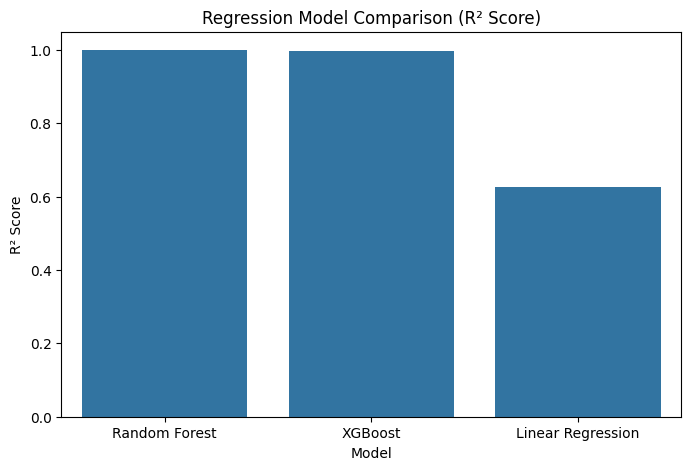

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_results,
    x="Model",
    y="R² Score"
)

plt.title("Regression Model Comparison (R² Score)")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

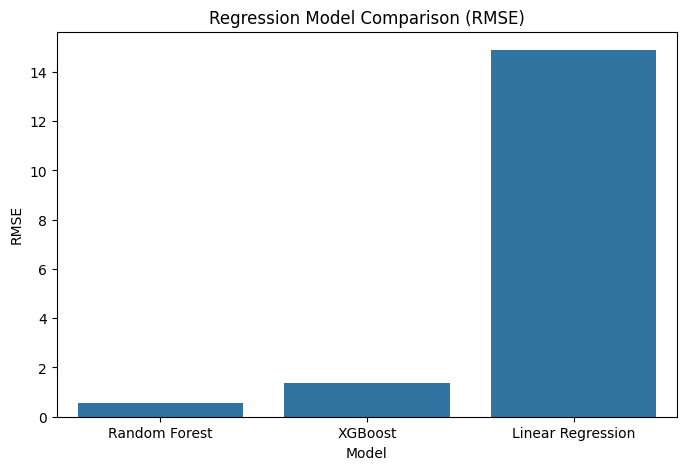

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_results,
    x="Model",
    y="RMSE"
)

plt.title("Regression Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

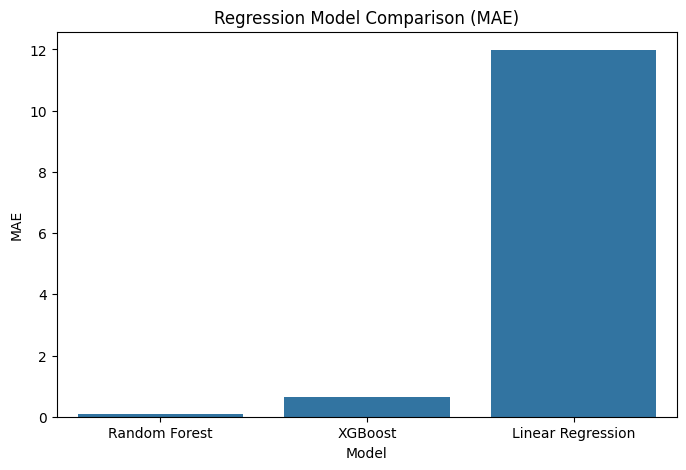

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=regression_results,
    x="Model",
    y="MAE"
)

plt.title("Regression Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.show()

# Classification with XGBoost

In [19]:
def categorize_aqi(aqi):

    if aqi <= 50:
        return 0

    elif aqi <= 100:
        return 1

    elif aqi <= 150:
        return 2

    else:
        return 3

In [20]:
df["aqi_category"] = df["aqi"].apply(categorize_aqi)

In [21]:
X = df.drop(["aqi", "aqi_category"], axis=1)

y = df["aqi_category"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_clf.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:
xgb_class_pred = xgb_clf.predict(X_test)

# Evaluate Classification

In [27]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_class_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_class_pred,
    average="weighted"
)

xgb_recall = recall_score(
    y_test,
    xgb_class_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test,
    xgb_class_pred,
    average="weighted"
)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall :", xgb_recall)
print("F1 Score :", xgb_f1)
print(classification_report(y_test, xgb_class_pred))

Accuracy : 0.9958333333333333
Precision: 0.995927200727963
Recall : 0.9958333333333333
F1 Score : 0.9958615794923127
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00      1628
           2       1.00      0.99      1.00      1818
           3       0.94      0.98      0.96       130

    accuracy                           1.00      3600
   macro avg       0.98      0.99      0.99      3600
weighted avg       1.00      1.00      1.00      3600



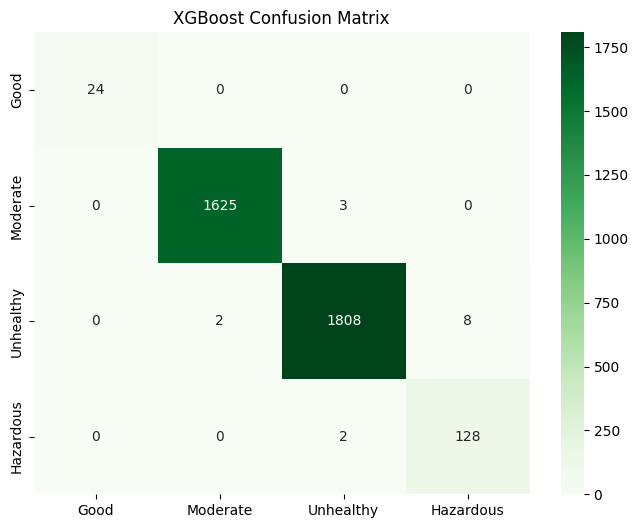

In [28]:
cm = confusion_matrix(
    y_test,
    xgb_class_pred
)

plt.figure(figsize=(8,6))

labels = ["Good", "Moderate", "Unhealthy", "Hazardous"]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("XGBoost Confusion Matrix")

plt.show()

# Save Best Models

In [31]:
best_classifier = xgb_clf
best_regressor = xgb_reg

In [32]:
joblib.dump(best_regressor, "../models/xgboost_regressor.pkl")
joblib.dump(best_classifier, "../models/xgboost_classifier.pkl")

['../models/xgboost_classifier.pkl']

In [ ]:
# Phase 5 Completed

## Conclusion

# In this phase, advanced machine learning models were developed using the XGBoost algorithm for both regression and classification tasks. Their performance was evaluated using appropriate evaluation metrics and compared with baseline machine learning models.

# The trained XGBoost Regressor and XGBoost Classifier demonstrated strong predictive performance and were saved as serialized model files (`.pkl`) for deployment in the AirPulse AI application.

# This phase completes the machine learning pipeline and prepares the project for building an interactive dashboard.